# Backward Repetition Lag-CRP

> Measure how strongly repeated items attract incoming transitions from temporal neighbors.

The incoming ("clean backward") repetition CRP reverses each recall sequence before computing the standard repetition CRP. This measures the conditional probability of transitioning *to* a repeated item as a function of lag from each of its study positions, rather than transitioning *from* a repeated item. The analysis reveals how strongly repeated items attract incoming transitions from their temporal neighbors.

## Workflow

In [1]:
import matplotlib.pyplot as plt
import os
from jaxcmr.analyses.cleanbackrepcrp import (
    plot_back_rep_crp,
    subject_back_rep_crp,
    test_back_rep_crp_vs_control,
    test_first_second_bias,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure
from jaxcmr.repetition import make_control_dataset

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] > 2"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
min_lag = 4
max_lag = 5
size = 2
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)
control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

/Users/jordangunn/workspace/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


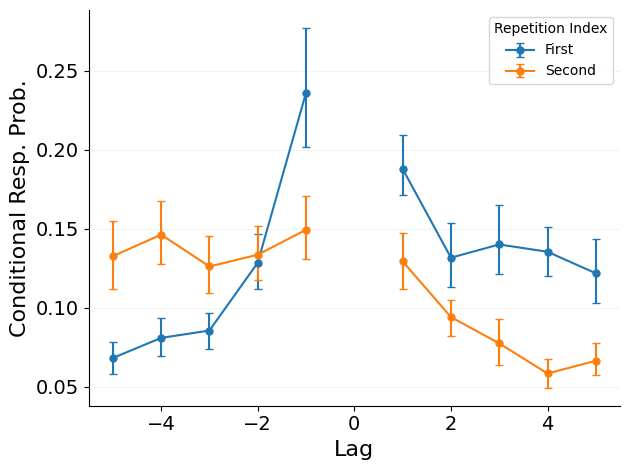

/Users/jordangunn/workspace/.venv/lib/python3.12/site-packages/scipy/stats/_resampling.py:141: RuntimeWarning: invalid value encountered in subtract
  U_ji = [(n - 1) * (theta_hat_dot - theta_hat_i)


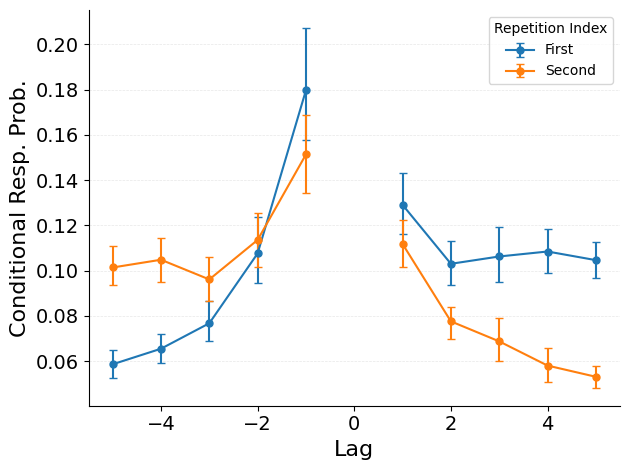

In [4]:
plot_back_rep_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    confidence_level=confidence_level,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="mixed")

plot_back_rep_crp(
    datasets=control_dataset,
    trial_masks=control_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    confidence_level=confidence_level,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str, suffix="control")

In [5]:
observed_crp = subject_back_rep_crp(data, trial_mask, min_lag, max_lag, size)
control_crp = subject_back_rep_crp(control_dataset, control_mask, min_lag, max_lag, size)

results = test_back_rep_crp_vs_control(observed_crp, control_crp, max_lag)
for label, result in results.items():
    print(f"\n{'='*60}")
    print(f"Statistical Tests: {label}")
    print(f"{'='*60}")
    print(result)

bias_result = test_first_second_bias(observed_crp, control_crp, max_lag)
print(f"\n{'='*70}")
print("Test: First-Second Bias (Observed) vs First-Second Bias (Control)")
print(f"{'='*70}")
print(bias_result)


Statistical Tests: First Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+----------------------+------------
   -5 |    1.459     0.1538 |    236.0     0.2012 |     0.0097
   -4 |    2.398     0.0221 |    183.0     0.0300 |     0.0155
   -3 |    1.339     0.1893 |    224.0     0.2089 |     0.0089
   -2 |    2.337     0.0255 |    189.0     0.0387 |     0.0209
   -1 |    4.700     0.0000 |     72.0     0.0000 |     0.0562
    0 |      nan        nan |      nan        nan |        nan
    1 |    5.312     0.0000 |     62.0     0.0000 |     0.0587
    2 |    2.983     0.0053 |    181.0     0.0275 |     0.0286
    3 |    3.766     0.0006 |    112.0     0.0015 |     0.0338
    4 |    3.478     0.0014 |    133.0     0.0022 |     0.0270
    5 |    1.697     0.0989 |    247.0     0.2726 |     0.0172

Statistical Tests: Second Presentation
  Lag |   t-stat    t p-val |   W-stat    W p-val |  Mean Diff
------+----------------------+------

/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/cleanbackrepcrp.py:266: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_col, ctrl_col, nan_policy="omit")
/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/cleanbackrepcrp.py:277: RuntimeWarning: Mean of empty slice
  mean_diffs[lag_idx] = np.nanmean(diff)
/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/cleanbackrepcrp.py:322: RuntimeWarning: invalid value encountered in subtract
  control_diff = control_crp[:, 0, :] - control_crp[:, 1, :]
/Users/jordangunn/workspace/jaxcmr/jaxcmr/analyses/cleanbackrepcrp.py:336: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_rel(obs_d, ctrl_d, nan_policy="omit")
/Users/jordangunn/workspace/jaxcmr/j

## Interpretation

Two plots are produced: one for observed (mixed-list) data and one for the shuffled control. Each shows incoming transition curves by presentation index. Key patterns:

- **Incoming contiguity**: peaks near the repeated item's study positions indicate that neighbors attract transitions toward the repetition.
- **First vs. second presentation**: differences between curves reveal whether one occurrence attracts more incoming transitions than the other.
- **Observed vs. control**: differences isolate repetition-specific incoming attraction beyond shuffled baselines.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits, or `None` for automatic scaling.
- `mixed_trial_query` — query selecting trials with repeated items.
- `control_trial_query` — query selecting trials for the control.
- `control_shuffles` — number of shuffle iterations for building the control dataset.
- `min_lag` — minimum absolute lag included in the analysis.
- `max_lag` — maximum absolute lag displayed.
- `size` — maximum number of study positions a single item can occupy.
- `confidence_level` — confidence level for subject-wise error bars.